# Solar Flux Prediction

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp/tmux-1022/default,126489,1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
print("--- Daily Loading and Aggregation ---")
df = pd.read_csv("../Data/MARSIS_historical_dataset.csv", sep=";")
df.columns = df.columns.str.strip()

# TIME CONVERSION
df['datetime'] = pd.to_datetime(df['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))

# daily aggregation
df_daily = df.groupby(df['datetime'].dt.to_period('D')).agg({
    'FM_data_F10_7_index': 'mean'
}).reset_index()

df_daily['datetime'] = df_daily['datetime'].dt.to_timestamp()

# Filling in missing days before extracting temporal features
df_daily = df_daily.set_index('datetime').asfreq('D', method='ffill').reset_index()

# Temporal feature extraction (now based on a perfect calendar with no gaps)
df_daily['day_of_year'] = df_daily['datetime'].dt.dayofyear
df_daily['day_sin'] = np.sin(2 * np.pi * df_daily['day_of_year'] / 365.25)
df_daily['day_cos'] = np.cos(2 * np.pi * df_daily['day_of_year'] / 365.25)

print(f"Daily dataset created. Total days available: {len(df_daily)}")

--- Daily Loading and Aggregation ---
Daily dataset created. Total days available: 5532


In [5]:
import numpy as np
from time_series_utils import *

LOOKBACK_WINDOW = 30 

# creating the matrices using the daily dataset and the day of the year
X_flux, X_time, y = create_dataset_windows(
    data=df_daily, 
    target_col='FM_data_F10_7_index', 
    time_col=['day_sin', 'day_cos'],  
    lookback=LOOKBACK_WINDOW
)

# Split Cronologico (80% Train, 20% Test)
split_idx = int(len(y) * 0.8)

X_flux_train, X_flux_test = X_flux[:split_idx], X_flux[split_idx:]
X_time_train, X_time_test = X_time[:split_idx], X_time[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

## Linear regression for solar flux prediction 

In [6]:
print("\n--- Training: Linear regression ---")

# combining the features
X_time_train_flat = X_time_train.reshape(X_time_train.shape[0], -1)
X_time_test_flat = X_time_test.reshape(X_time_test.shape[0], -1)

# combining the flux and the flattened temporal coordinates
X_linear_train = np.hstack((X_flux_train, X_time_train_flat))
X_linear_test = np.hstack((X_flux_test, X_time_test_flat))

# initialization and fit
lr_model = LinearRegression()
lr_model.fit(X_linear_train, y_train)

# prediction and evaluation
y_pred_lr = lr_model.predict(X_linear_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"[Linear Regression] Test MAE: {mae_lr:.3f}, Test RMSE: {rmse_lr:.3f}")


--- Training: Linear regression ---
[Linear Regression] Test MAE: 0.411, Test RMSE: 1.382


## LSTM for solar flux prediction

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

print("\n--- Training: PyTorch LSTM (Dati Giornalieri) ---")

# =====================================================================
# 1. NORMALIZZAZIONE E CREAZIONE TENSORE 3D
# =====================================================================
# Scaliamo SOLO Flusso e Target nel range [-1, 1]
scaler_X_flux = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_flux_train_scaled = scaler_X_flux.fit_transform(X_flux_train)
X_flux_test_scaled = scaler_X_flux.transform(X_flux_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# Le feature temporali (X_time_train) sono già tra -1 e 1 e hanno già forma (Campioni, 30, 2).
# Dobbiamo solo allineare le dimensioni del Flusso prima di unirle.
# Espandiamo il Flusso da (Campioni, 30) a (Campioni, 30, 1)
X_flux_train_3d = np.expand_dims(X_flux_train_scaled, axis=-1)
X_flux_test_3d = np.expand_dims(X_flux_test_scaled, axis=-1)

# COSTRUIAMO L'INPUT 3D RICHIESTO DALLA LSTM: (Campioni, Finestra, Feature)
# Uniamo lungo l'ultimo asse (1 colonna Flusso + 2 colonne Tempo = 3 Feature totali)
X_lstm_train = np.concatenate((X_flux_train_3d, X_time_train), axis=-1)
X_lstm_test = np.concatenate((X_flux_test_3d, X_time_test), axis=-1)


--- Training: PyTorch LSTM (Dati Giornalieri) ---


### 100 epochs

In [8]:
from utils.train_pytorch_model import *
from models.LSTM import *

# Avviamo l'addestramento usando la funzione modificata
# Passiamo hidden_dim=32 alla fine; verrà catturato da **model_kwargs
trained_lstm, device, training_history = train_pytorch_model(
    X_train=X_lstm_train,         # I tuoi dati 3D (Campioni, 30, 2)
    y_train=y_train_scaled,       # Il target normalizzato
    input_dim=3,                  # Flusso solare + Giorno dell'anno
    model_class=LSTMRegressor,    # La classe del modello
    epochs=100,                   # Massimo numero di epoche
    patience=8,                   # Interrompi se la val_loss non migliora per 8 epoche
    batch_size=32,                # Dimensione del batch ottimale per dati giornalieri
    hidden_dim=32                 # <--- Parametro extra inoltrato alla LSTM!
)

# =====================================================================
# INFERENZA SUI DATI DI TEST (Utilizzando il modello addestrato)
# =====================================================================
trained_lstm.eval()
X_test_t = torch.tensor(X_lstm_test, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_lstm_scaled = trained_lstm(X_test_t).cpu().numpy()

# De-normalizzazione per visualizzare i risultati in scala reale
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Calcolo delle metriche di performance finali
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"\n[LSTM Network] Test MAE: {mae_lstm:.3f}, Test RMSE: {rmse_lstm:.3f}")

Early stopping at epoch 70

[LSTM Network] Test MAE: 0.608, Test RMSE: 1.324



Grafici salvati con successo in:
- plots/lstm_training_history_20260723_114422.png
- plots/lstm_training_history_20260723_114422.pdf


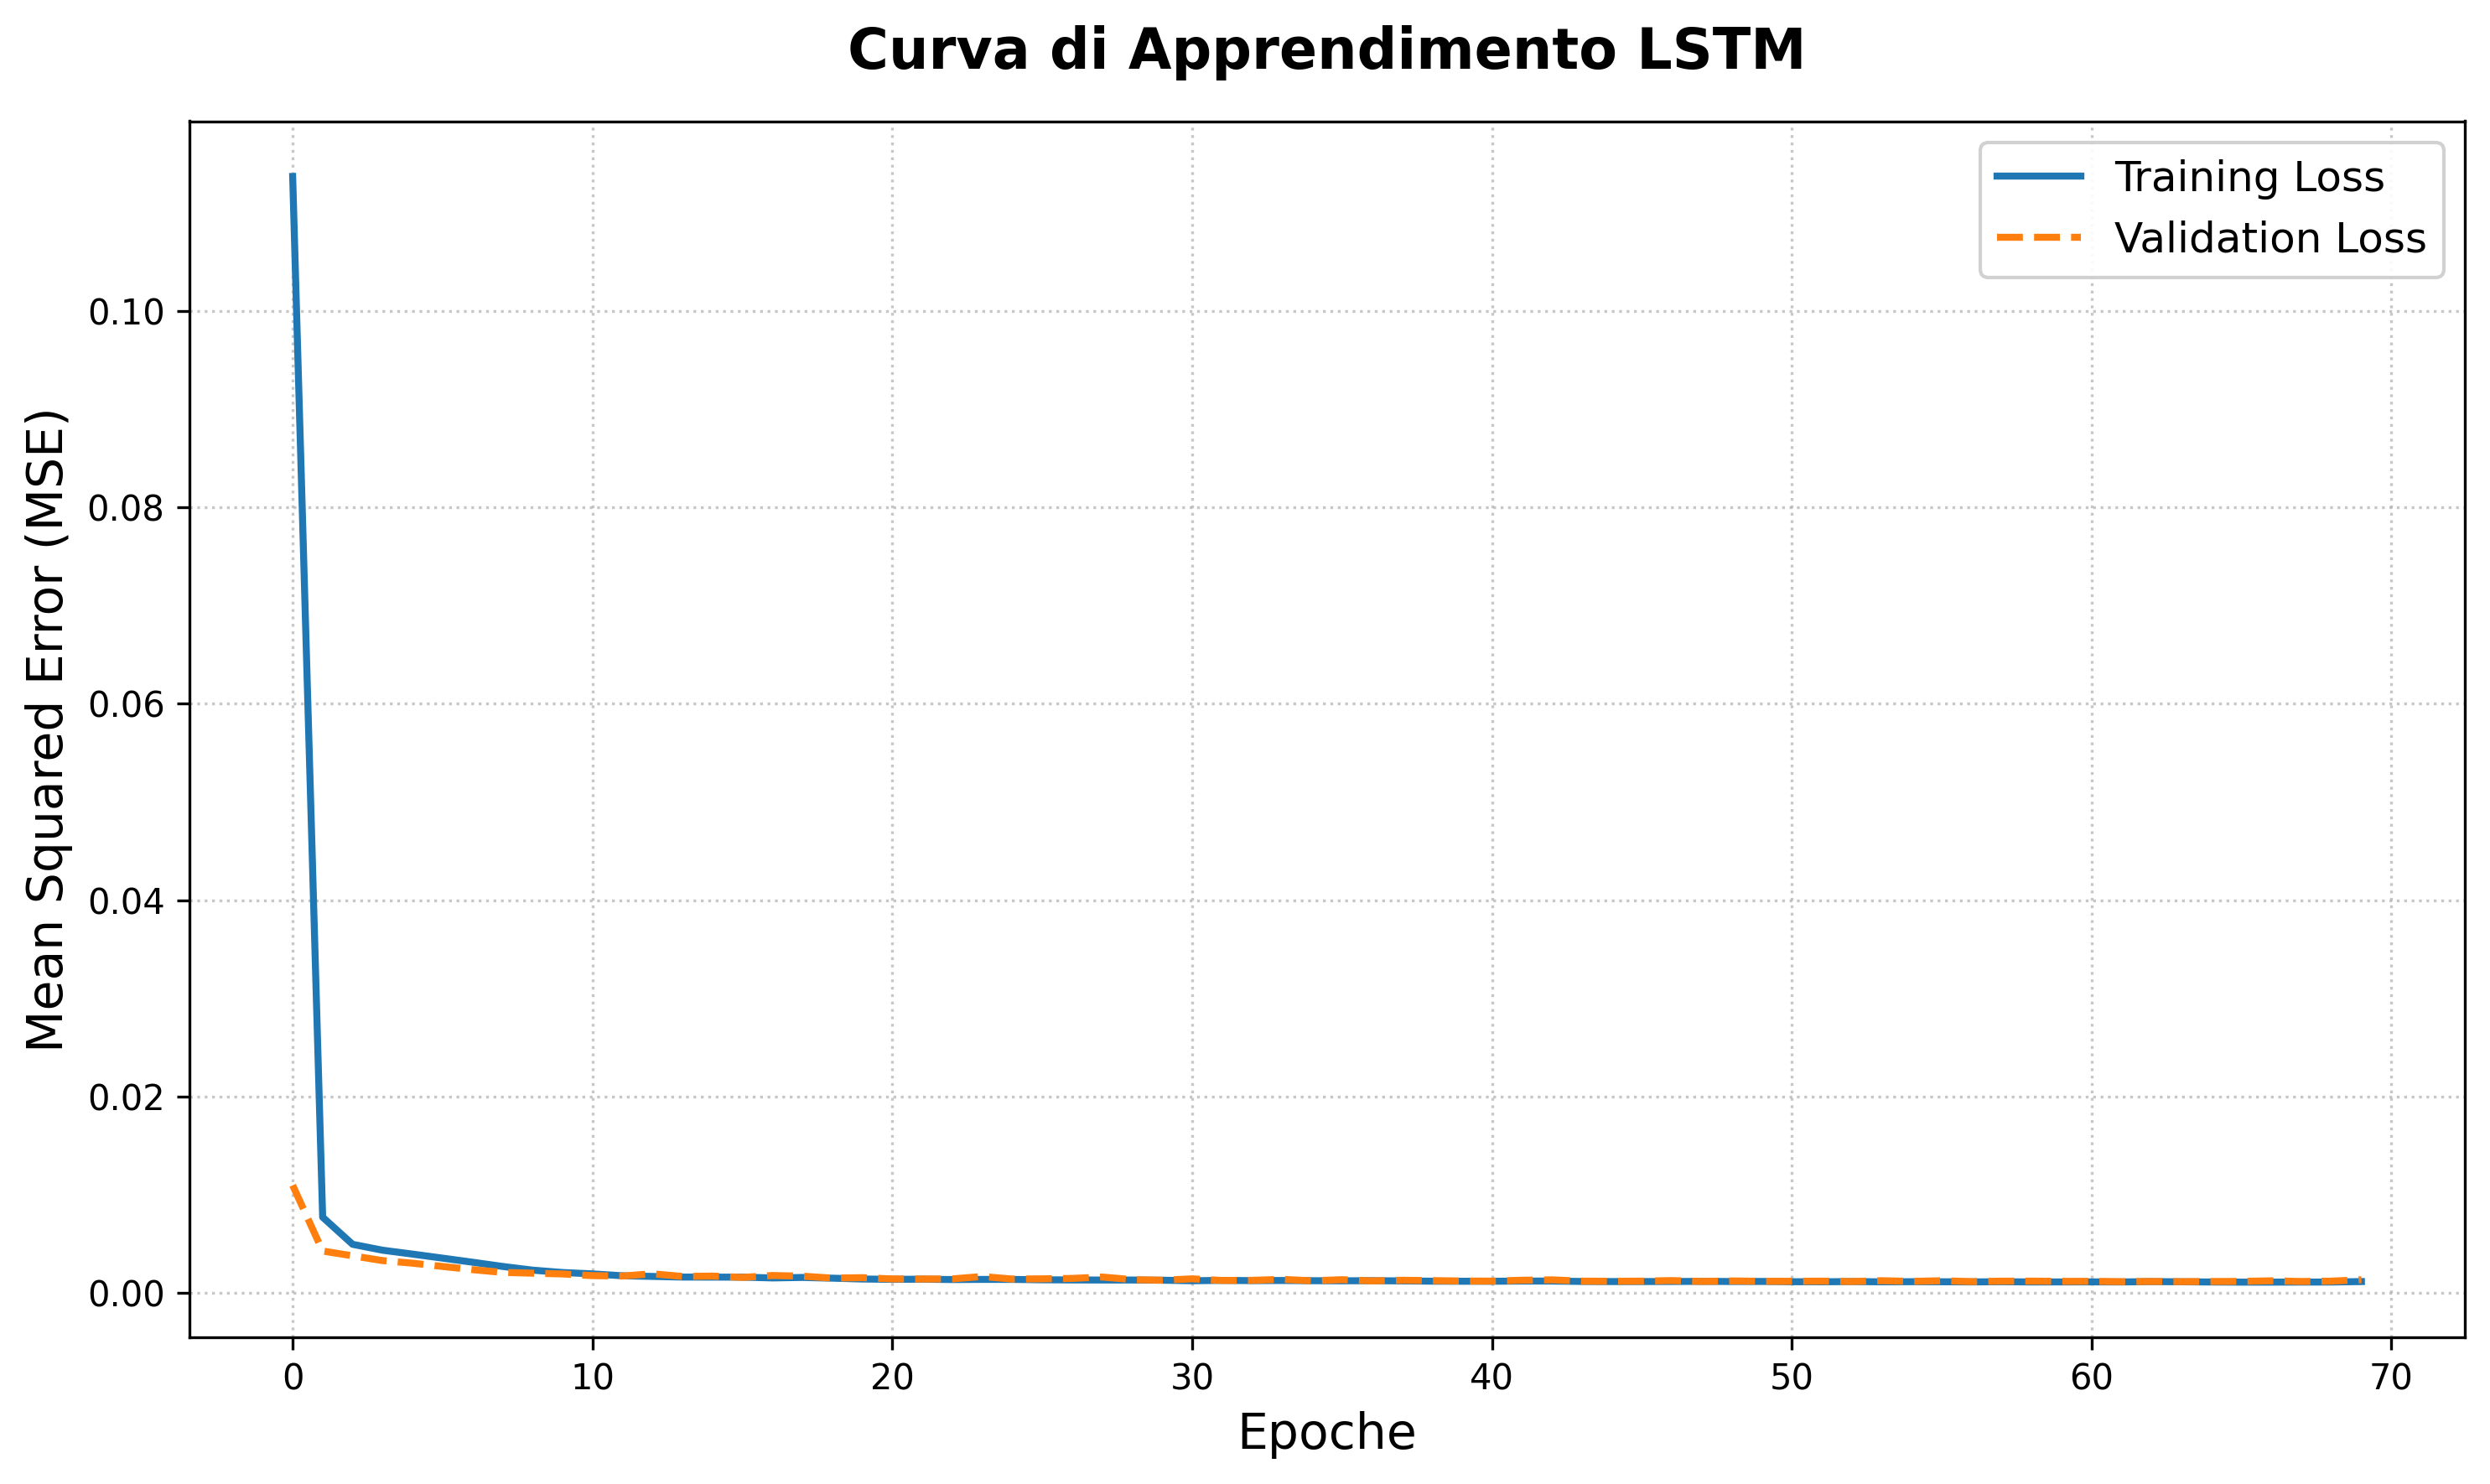

In [9]:
plot_and_save_history(training_history, save_dir="plots")

### 1000 epochs

In [10]:
from utils.train_pytorch_model import *
from models.LSTM import *

# Avviamo l'addestramento usando la tua funzione modificata
# Passiamo hidden_dim=32 alla fine; verrà catturato da **model_kwargs
trained_lstm_2, device_2, training_history_2 = train_pytorch_model(
    X_train=X_lstm_train,         # I tuoi dati 3D (Campioni, 30, 2)
    y_train=y_train_scaled,       # Il target normalizzato
    input_dim=3,                  # Flusso solare + Giorno dell'anno
    model_class=LSTMRegressor,    # La classe del modello
    epochs=1000,                   # Massimo numero di epoche
    patience=8,                   # Interrompi se la val_loss non migliora per 8 epoche
    batch_size=64,                # Dimensione del batch ottimale per dati giornalieri
    hidden_dim=256                 # <--- Parametro extra inoltrato alla LSTM!
)

# =====================================================================
# INFERENZA SUI DATI DI TEST (Utilizzando il modello addestrato)
# =====================================================================
trained_lstm_2.eval()
X_test_t_2 = torch.tensor(X_lstm_test, dtype=torch.float32).to(device_2)

with torch.no_grad():
    y_pred_lstm_scaled_2 = trained_lstm_2(X_test_t_2).cpu().numpy()

# De-normalizzazione per visualizzare i risultati in scala reale
y_pred_lstm_2 = scaler_y.inverse_transform(y_pred_lstm_scaled_2).flatten()

# Calcolo delle metriche di performance finali
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_lstm_2 = mean_absolute_error(y_test, y_pred_lstm_2)
rmse_lstm_2 = np.sqrt(mean_squared_error(y_test, y_pred_lstm_2))

print(f"\n[LSTM Network] Test MAE: {mae_lstm_2:.3f}, Test RMSE: {rmse_lstm_2:.3f}")

Early stopping at epoch 63

[LSTM Network] Test MAE: 0.432, Test RMSE: 1.271



Grafici salvati con successo in:
- plots/lstm_training_history_20260723_114442.png
- plots/lstm_training_history_20260723_114442.pdf


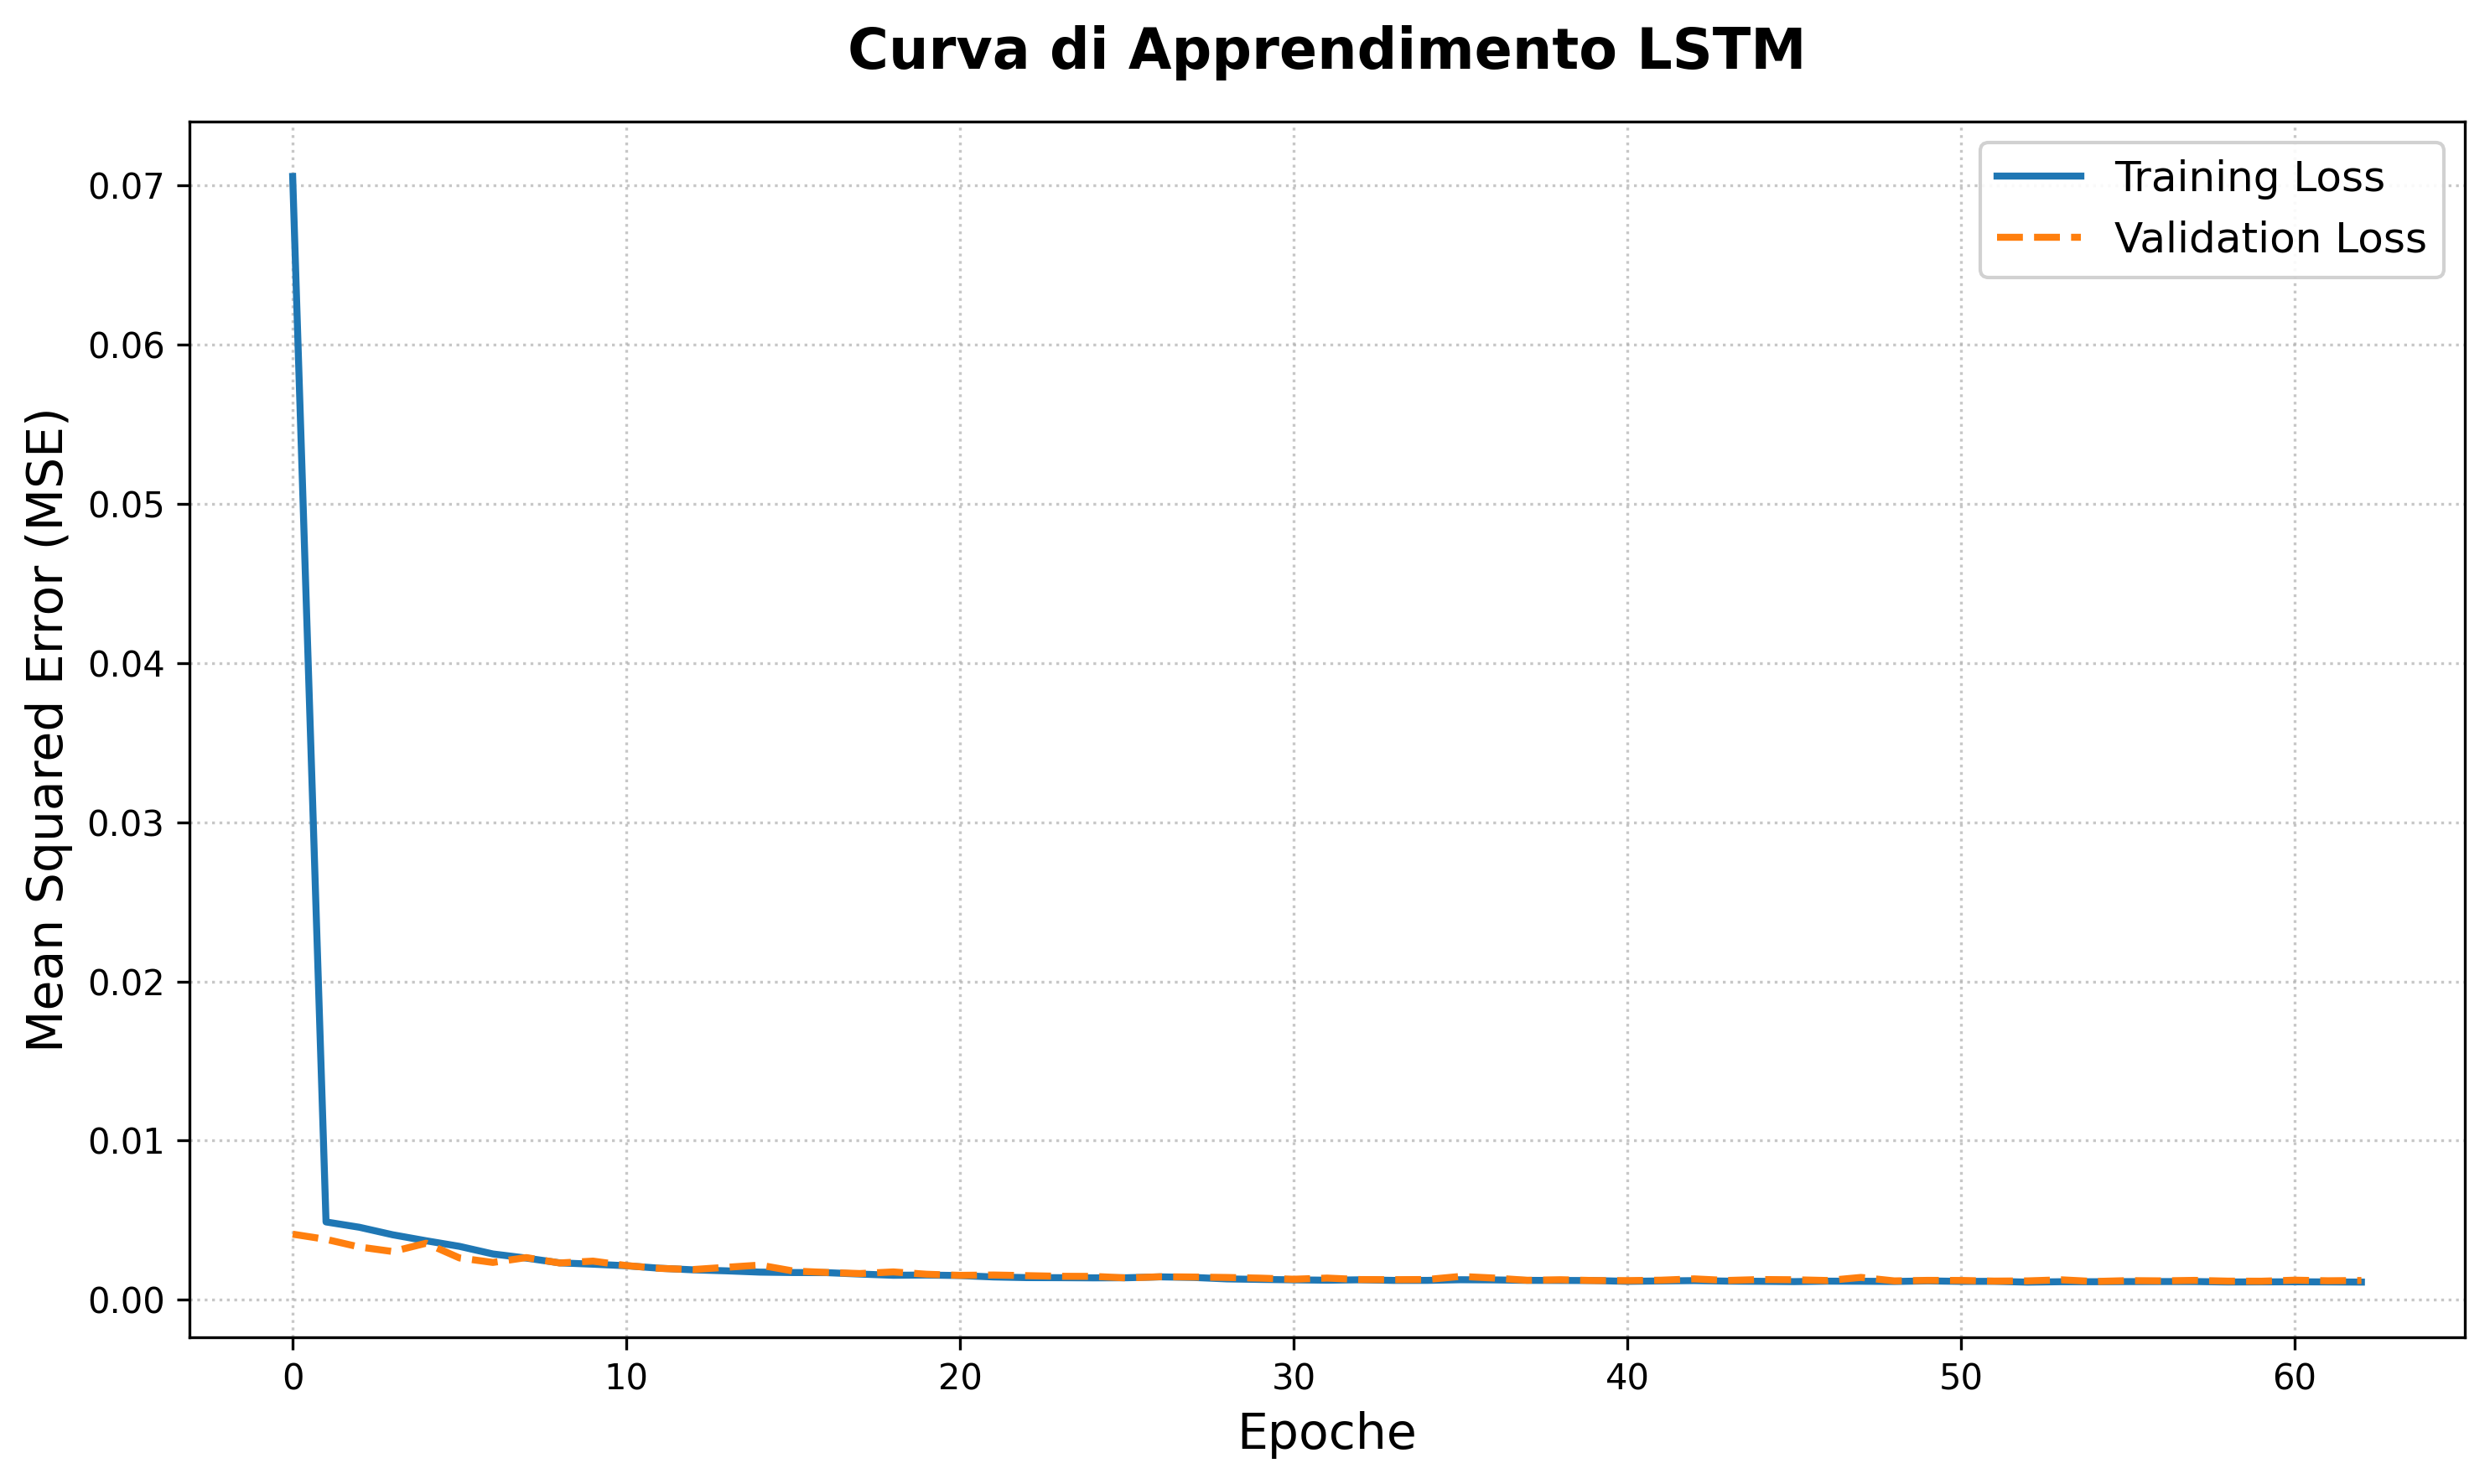

In [11]:
plot_and_save_history(training_history_2, save_dir="plots")

## Saving models

In [12]:
from time_series_utils import *

# TODO: check only the following cell

In [11]:
# Impacchettiamo gli scaler in un dizionario
my_scalers = {
    'scaler_X_flux': scaler_X_flux,
    'scaler_X_time': scaler_X_time,
    'scaler_y': scaler_y
}

save_lstm_and_scalers(
    model=trained_lstm, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_100_epochs.pth", 
    scaler_name="lstm_scalers_100_epochs.pkl"
)

# Chiamiamo la funzione
save_lstm_and_scalers(
    model=trained_lstm_2, 
    scalers_dict=my_scalers, 
    save_dir="saved_lstm", 
    model_name="lstm_1000_epochs.pth", 
    scaler_name="lstm_scalers_1000_epochs.pkl"
)

✅ Operazione completata con successo!
   - Pesi modello salvati in: saved_lstm/lstm_100_epochs_20260525_195718.pth
   - Scaler salvati in:       saved_lstm/lstm_scalers_100_epochs_20260525_195718.pkl
✅ Operazione completata con successo!
   - Pesi modello salvati in: saved_lstm/lstm_1000_epochs_20260525_195718.pth
   - Scaler salvati in:       saved_lstm/lstm_scalers_1000_epochs_20260525_195718.pkl


### Creating artificial Test Set with LSTM predicted values

In [13]:
print("--- 1. Creazione del DataFrame delle predizioni LSTM (Out-of-Sample) ---")

# L'array 'y' dell'LSTM parte dopo LOOKBACK_WINDOW giorni.
# Lo split_idx definisce dove inizia il Test Set.
start_test_idx = LOOKBACK_WINDOW + split_idx

# Estraiamo le date esatte del Test Set
dates_for_lstm_test = df_daily['datetime'].iloc[start_test_idx:].values

# Creiamo un DataFrame con le predizioni cieche dell'LSTM a 1000 epoche
df_lstm_blind_test = pd.DataFrame({
    'datetime': dates_for_lstm_test,
    'Predicted_F10_7': y_pred_lstm_2
})

# Troviamo la data esatta in cui inizia il Test Set cronologico
split_date = df_lstm_blind_test['datetime'].min()
print(f"Lo split cronologico Train/Test avviene in data: {split_date}")
print(f"Giorni nel Test Set Cieco dell'LSTM: {len(df_lstm_blind_test)}")

--- 1. Creazione del DataFrame delle predizioni LSTM (Out-of-Sample) ---
Lo split cronologico Train/Test avviene in data: 2018-01-23 00:00:00
Giorni nel Test Set Cieco dell'LSTM: 1101


In [14]:
print("\n--- 2. Allineamento Temporale (Merge Asof) sui dati MARSIS ---")

# Effettuiamo una deep copy del dataset originale per non alterarlo
df_main_copy = df.copy(deep=True)

# Filtriamo MARSIS prendendo SOLO i dati successivi alla data di split
df_marsis_test_only = df[df['datetime'] >= split_date].copy()

# =====================================================================
# CORREZIONE AUTOMATICA: Allineamento della precisione temporale [ns]
# =====================================================================
df_marsis_test_only['datetime'] = df_marsis_test_only['datetime'].astype('datetime64[ns]')
df_lstm_blind_test['datetime'] = df_lstm_blind_test['datetime'].astype('datetime64[ns]')

# Ordiniamo per il merge asincrono (ora i tipi coincidono perfettamente)
df_marsis_test_only = df_marsis_test_only.sort_values('datetime').reset_index(drop=True)
df_lstm_blind_test = df_lstm_blind_test.sort_values('datetime').reset_index(drop=True)

# Merge: a ogni riga MARSIS viene associata la predizione LSTM del giorno corrente/precedente
df_cascade_test = pd.merge_asof(
    df_marsis_test_only,
    df_lstm_blind_test,
    on='datetime',
    direction='backward'
)

# Rimuoviamo eventuali NaN nel caso ci siano disallineamenti iniziali
df_cascade_test = df_cascade_test.dropna(subset=['Predicted_F10_7'])
print(f" Righe MARSIS nel Test Set Operativo: {len(df_cascade_test)}")


--- 2. Allineamento Temporale (Merge Asof) sui dati MARSIS ---
 Righe MARSIS nel Test Set Operativo: 899137


In [15]:
print("\n--- 3. Generazione dei Dataset di Test (Ideale vs Cascata) ---")

# SCENARIO 1: IDEALE (Controllo) - Usiamo i dati reali
df_test_ideal = df_cascade_test.copy(deep=True)
# (La colonna FM_data_F10_7_index rimane quella originale vera)

# SCENARIO 2: CASCATA (Produzione) - Inganniamo il modello con le stime LSTM
df_test_cascade = df_cascade_test.copy(deep=True)
df_test_cascade['FM_data_F10_7_index'] = df_test_cascade['Predicted_F10_7']

# Rimuoviamo la colonna di appoggio che non serve più
df_test_ideal = df_test_ideal.drop(columns=['Predicted_F10_7'])
df_test_cascade = df_test_cascade.drop(columns=['Predicted_F10_7'])

# Salvataggio su disco (opzionale ma consigliato per debug)
os.makedirs("../Data/Test_Sets", exist_ok=True)
# Generazione del timestamp univoco
timestamp_safe = datetime.now().strftime("%Y%m%d_%H%M%S")

# Definizione dei percorsi con il timestamp integrato
path_ideal = f"../Data/Test_Sets/MARSIS_Test_Ideal_{timestamp_safe}.csv"
path_cascade = f"../Data/Test_Sets/MARSIS_Test_Cascade_{timestamp_safe}.csv"

# Salvataggio su disco
df_test_ideal.to_csv(path_ideal, sep=";", index=False)
df_test_cascade.to_csv(path_cascade, sep=";", index=False)

print(f"File salvati con successo in ../Data/Test_Sets/:")
print(f"- {path_ideal}")
print(f"- {path_cascade}")


--- 3. Generazione dei Dataset di Test (Ideale vs Cascata) ---
File salvati con successo in ../Data/Test_Sets/:
- ../Data/Test_Sets/MARSIS_Test_Ideal_20260723_114533.csv
- ../Data/Test_Sets/MARSIS_Test_Cascade_20260723_114533.csv


In [16]:
from utils.data_processing import *

# =====================================================================
# STEP 1: GENERAZIONE DEL TRAIN SET (L'80% CRONOLOGICO ANTECEDENTE)
# =====================================================================
print("--- 1. Isolamento e salvataggio del Train Set (80%) ---")

# Prendiamo i dati storici antecedenti alla data di split dell'LSTM
df_marsis_train_only = df[df['datetime'] < split_date].copy()

# Rimuoviamo la colonna 'datetime' di servizio per ripristinare il formato MARSIS originale
df_marsis_train_only = df_marsis_train_only.drop(columns=['datetime'], errors='ignore')

timestamp_export = datetime.now().strftime("%Y%m%d_%H%M%S")
train_csv_path = f"../Data/Test_Sets/MARSIS_Train_Pure_{timestamp_export}.csv"
df_marsis_train_only.to_csv(train_csv_path, sep=";", index=False)
print(f"Train Set originale salvato in: {train_csv_path}")


# =====================================================================
# STEP 2: PULIZIA E SALVATAGGIO DEI DATASET DI TEST 
# =====================================================================
print("\n--- 2. Adeguamento e salvataggio dei Test Set (Ideale e Cascata) ---")

# Riprendiamo df_test_ideal e df_test_cascade e puliamo la colonna 'datetime'
df_test_ideal_save = df_test_ideal.drop(columns=['datetime'], errors='ignore')
df_test_cascade_save = df_test_cascade.drop(columns=['datetime'], errors='ignore')

# Definiamo i percorsi di salvataggio
ideal_csv_path = f"../Data/Test_Sets/MARSIS_Test_Ideal_{timestamp_export}.csv"
cascade_csv_path = f"../Data/Test_Sets/MARSIS_Test_Cascade_{timestamp_export}.csv"

# Salvataggio definitivo dei file puliti
df_test_ideal_save.to_csv(ideal_csv_path, sep=";", index=False)
df_test_cascade_save.to_csv(cascade_csv_path, sep=";", index=False)
print("File di Test salvati correttamente pronti per la pipeline.")


# =====================================================================
# STEP 3: ESTRAZIONE MATRICI X, y TRAMITE load_and_preprocess_data
# =====================================================================
print("\n--- 3. Estrazione delle matrici finali tramite la pipeline standard ---")

# Definiamo il percorso del file delle orbite da escludere (adattalo se differisce)
orbit_file_path = "../Data/orbit_to_remove" 

# 1. Dataset di Addestramento (Usa il flusso solare VERO)
X_train, y_train, feature_names = load_and_preprocess_data(
    dataset_path=train_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True # La rete principale HA BISOGNO del flusso solare per imparare
)

# 2. Dataset di Test IDEALE (Controllo con flusso solare VERO)
X_test_ideal, y_test_ideal, _ = load_and_preprocess_data(
    dataset_path=ideal_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)

# 3. Dataset di Test IN CASCATA (Operativo con flusso solare STIMATO DA LSTM)
X_test_cascade, y_test_cascade, _ = load_and_preprocess_data(
    dataset_path=cascade_csv_path, 
    orbit_path=orbit_file_path, 
    keep_flux=True
)


# =====================================================================
# STEP 4: VERIFICA DI INTEGRITÀ SCIENTIFICA
# =====================================================================
print("\n" + "="*50)
print("VERIFICA DIMENSIONI DATASET E COERENZA FEATURE")
print("="*50)
print(f"Features utilizzate ({len(feature_names)}): {feature_names}")
print("-" * 50)
print(f"TRAIN SET              -> X: {X_train.shape}  | y: {y_train.shape}")
print(f"TEST SET (IDEALE)     -> X: {X_test_ideal.shape}  | y: {y_test_ideal.shape}")
print(f"TEST SET (CASCATA)    -> X: {X_test_cascade.shape}  | y: {y_test_cascade.shape}")
print("-" * 50)

# Controllo fondamentale: i due test set devono essere matematicamente identici come shape
assert X_test_ideal.shape == X_test_cascade.shape, "ERRORE: Disallineamento tra Test Ideale e Cascata!"
assert np.array_equal(y_test_ideal, y_test_cascade), "ERRORE: I target (Echo Power) del test non coincidono!"
print("Tutto pronto! Le matrici sono allineate e prive di data leakage temporale.")

--- 1. Isolamento e salvataggio del Train Set (80%) ---
Train Set originale salvato in: ../Data/Test_Sets/MARSIS_Train_Pure_20260723_114720.csv

--- 2. Adeguamento e salvataggio dei Test Set (Ideale e Cascata) ---
File di Test salvati correttamente pronti per la pipeline.

--- 3. Estrazione delle matrici finali tramite la pipeline standard ---

VERIFICA DIMENSIONI DATASET E COERENZA FEATURE
Features utilizzate (19): ['FM_data_altitude', 'FM_data_band', 'FM_data_dipole_tilt', 'FM_data_F10_7_index', 'FM_data_latitude', 'FM_data_local_true_solar_time', 'FM_data_longitude', 'FM_data_Mars_Sun_distance', 'FM_data_monopole_tilt', 'FM_data_radial_magnetic_field', 'FM_data_roughness', 'FM_data_slope', 'FM_data_Sun_elevation_angle', 'FM_data_tangential_magnetic_field', 'FM_data_total_magnetic_field', 'FM_data_x_coordinate', 'FM_data_y_coordinate', 'FM_data_solar_longitude_cos', 'FM_data_solar_longitude_sin']
--------------------------------------------------
TRAIN SET              -> X: (1474165

### Model training

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import torch
import os
from datetime import datetime
from joblib import dump
from models.neural_network import *

print("--- 1. Standardizzazione delle Feature ---")
# Inizializziamo lo scaler per la rete neurale
scaler_nn = StandardScaler()

# Fit solo sul Train Set vero, transform su tutti per evitare data leakage
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_ideal_scaled = scaler_nn.transform(X_test_ideal)
X_test_cascade_scaled = scaler_nn.transform(X_test_cascade)

print("--- 2. Addestramento della NeurNet Singola ---")
# Usiamo direttamente la tua funzione di training
# Assumiamo che tu abbia importato o definito la classe del tuo modello, ad esempio 'NeurNet'
# Sostituisci 'NeurNet' con il nome reale della classe della tua rete
input_dimension = X_train_scaled.shape[1]

main_model, device, history = train_pytorch_model(
    X_train=X_train_scaled, 
    y_train=y_train, 
    input_dim=input_dimension, 
    model_class=NeurNet,  # <-- ATTENZIONE: Inserisci qui la TUA classe PyTorch
    epochs=1000, 
    patience=10, 
    batch_size=256
)

# Salvataggio del modello finale per sicurezza
os.makedirs("saved_main_model", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
scaler_save_path = f"saved_main_model/main_nn_scaler_{timestamp}.save"
torch.save(main_model.state_dict(), f"saved_main_model/main_nn_model_{timestamp}.pth")
dump(scaler_nn, scaler_save_path)
print("Modello principale addestrato e salvato.")
print(f"Scaler relativo salvato in: {scaler_save_path}")

--- 1. Standardizzazione delle Feature ---
--- 2. Addestramento della NeurNet Singola ---


Early stopping at epoch 12
Modello principale addestrato e salvato.
Scaler relativo salvato in: saved_main_model/main_nn_scaler_20260723_115253.save



Grafici salvati con successo in:
- plots/lstm_training_history_20260723_115347.png
- plots/lstm_training_history_20260723_115347.pdf


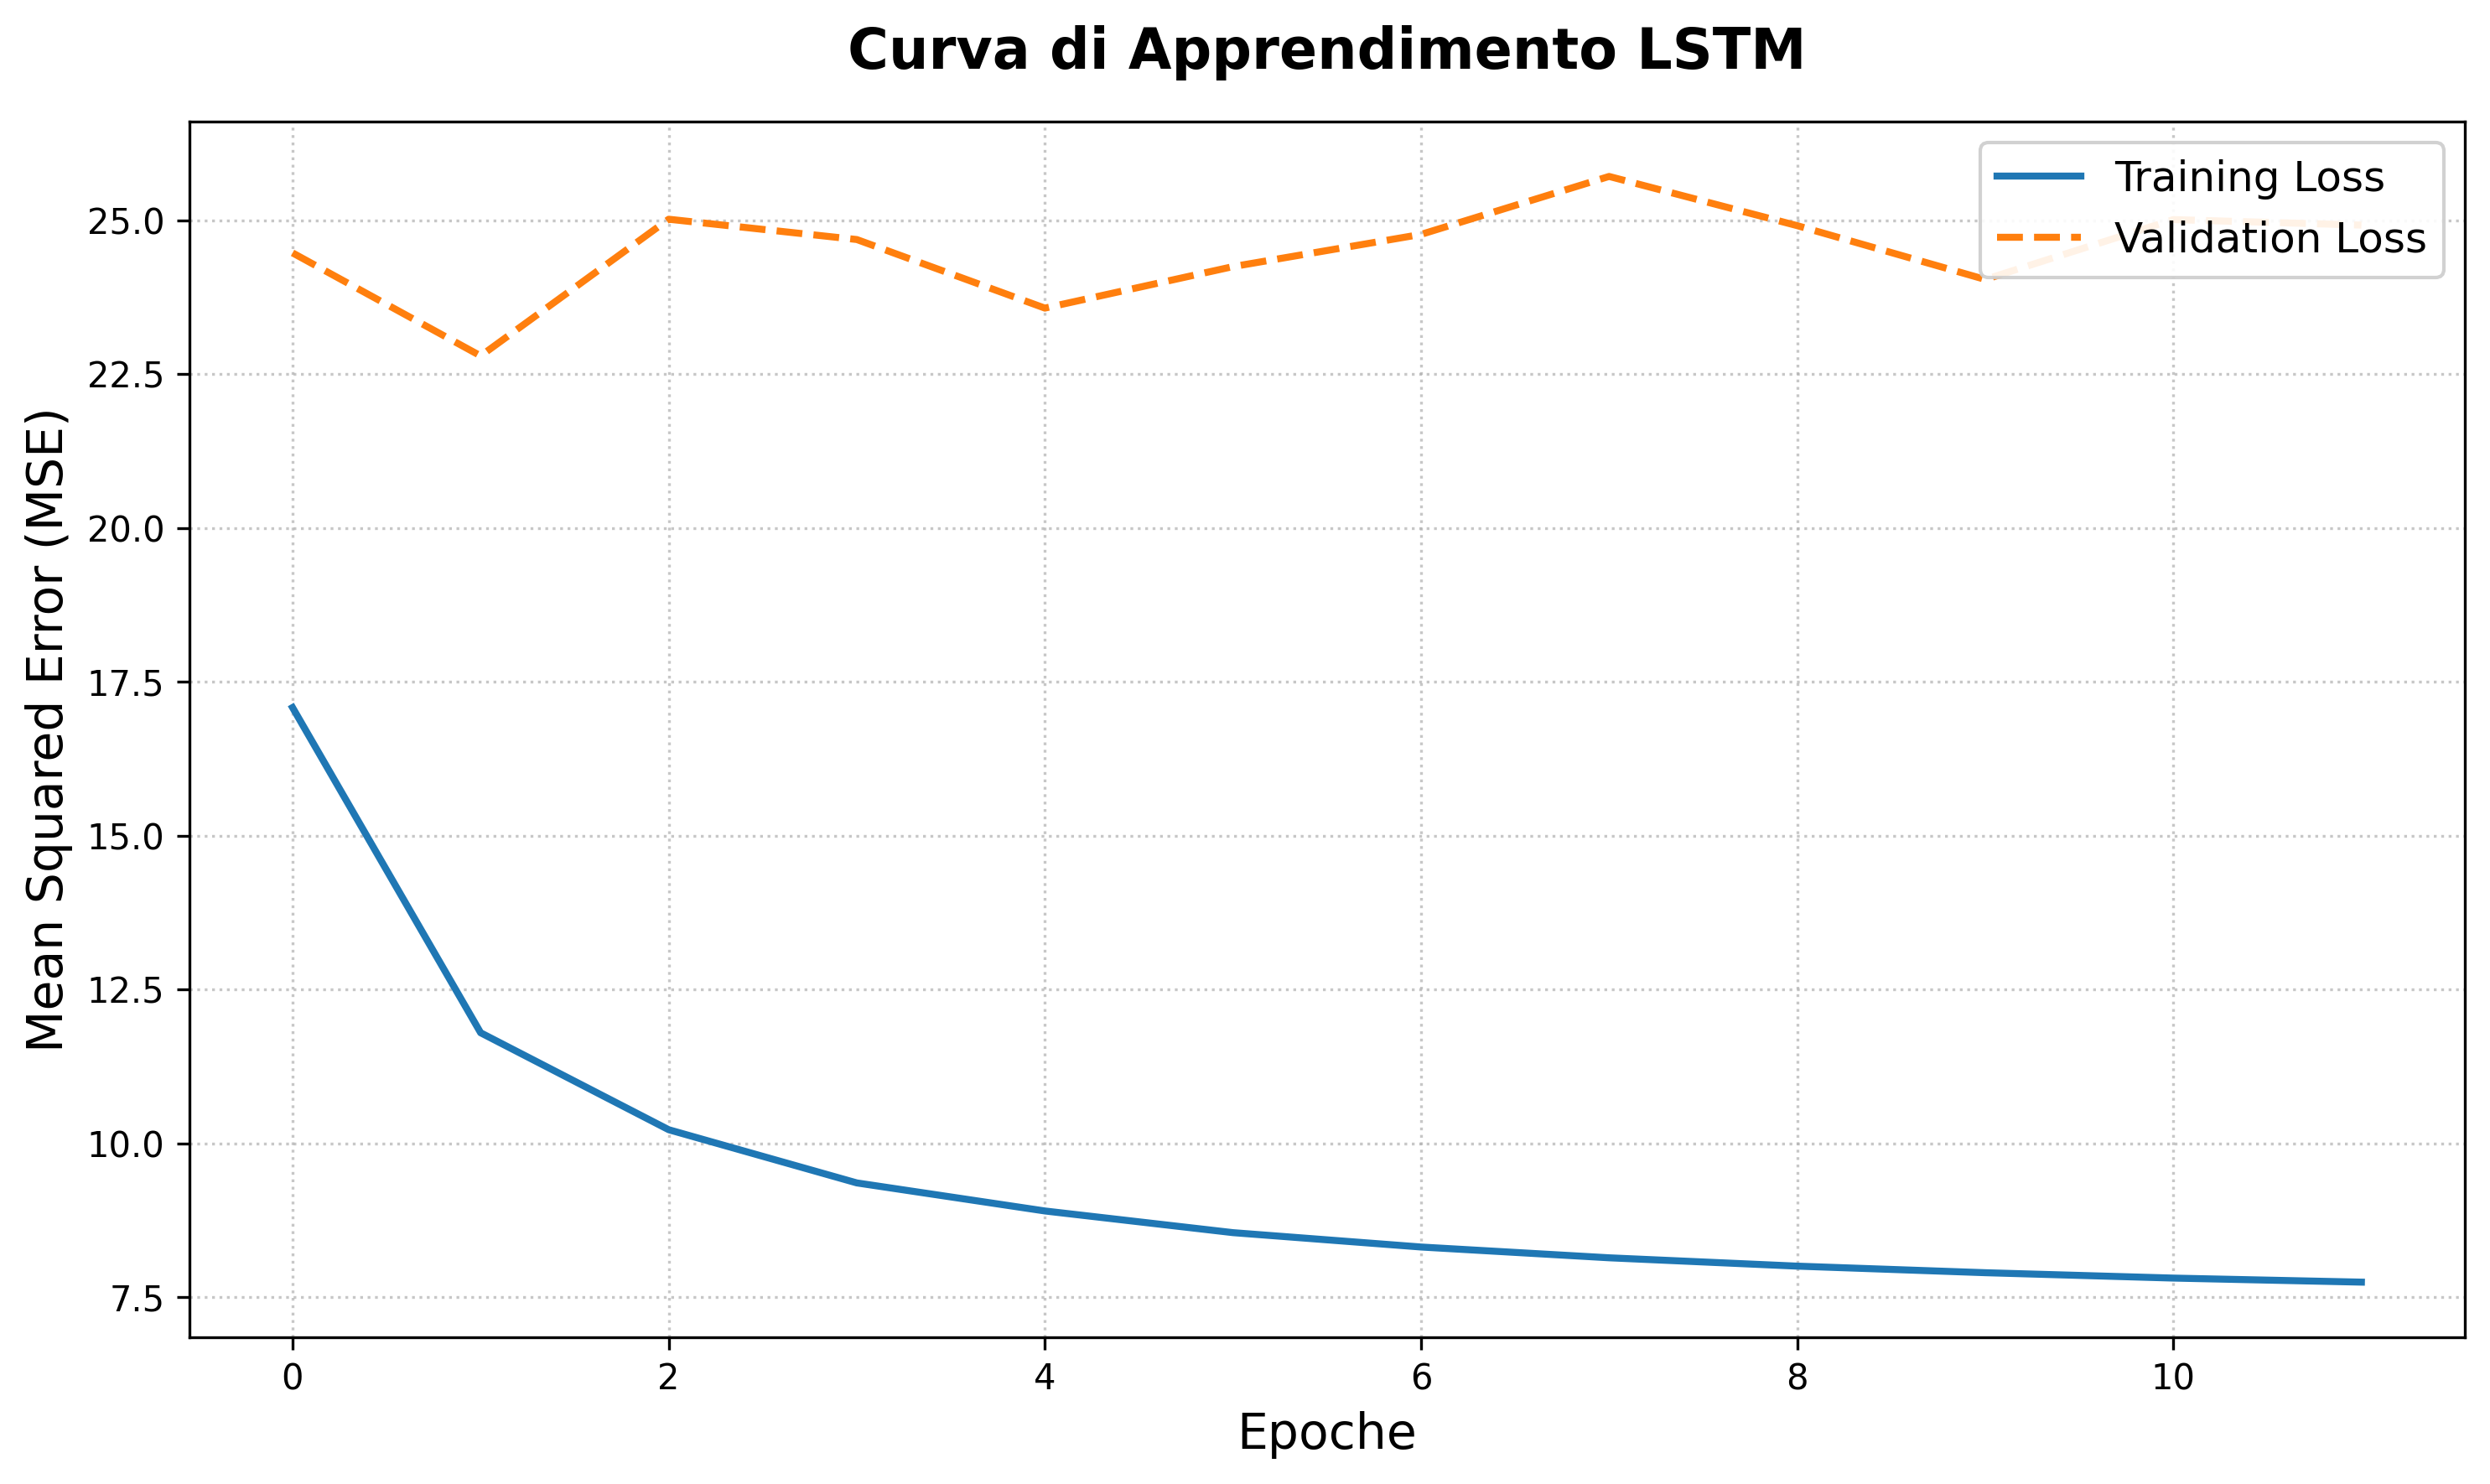

In [18]:
plot_and_save_history(history, save_dir="plots")

### Testing model on true data and on artificially engineered (LSTM) data


--- 3. Valutazione Comparativa sui due Scenari (Ideale vs Cascata) ---
REPORT FINALE: PERFORMANCE DELL'ESPERIMENTO A CASCATA
SCENARIO 1: FLUSSO SOLARE REALE (Baseline di Controllo)
  MAE:  2.4470
  RMSE: 3.1863
------------------------------------------------------------
SCENARIO 2: FLUSSO SOLARE DA LSTM (Simulazione Produzione)
  MAE:  2.4473
  RMSE: 3.1856
Degrado delle performance causato dal cascade post LSTM:
   Aumento del MAE:  +0.01%
   Aumento del RMSE: +-0.02%

Generazione del grafico comparativo unico...


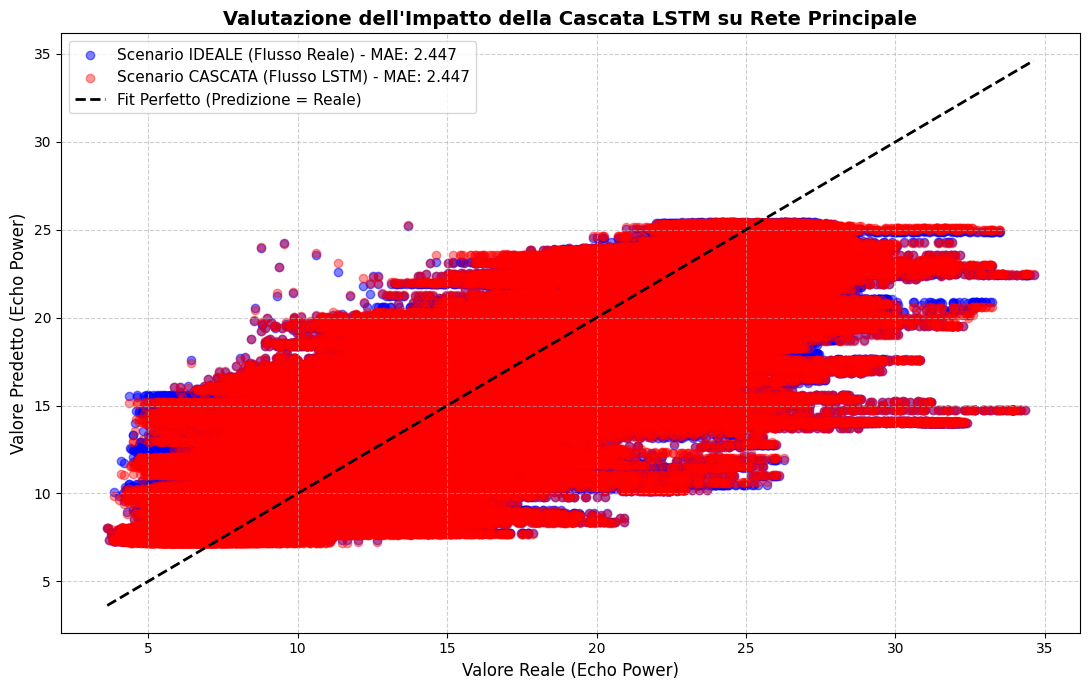

In [19]:
import matplotlib.pyplot as plt

print("\n--- 3. Valutazione Comparativa sui due Scenari (Ideale vs Cascata) ---")

# 1. Mettiamo il modello in modalità inferenza (disabilita Dropout, BatchNorm, etc.)
main_model.eval()

# 2. Convertiamo i Test Set (già scalati) in Tensori PyTorch
X_ideal_tensor = torch.tensor(X_test_ideal_scaled, dtype=torch.float32).to(device)
X_cascade_tensor = torch.tensor(X_test_cascade_scaled, dtype=torch.float32).to(device)

# 3. Eseguiamo l'inferenza senza calcolare i gradienti
with torch.no_grad():
    # .cpu().numpy().flatten() riporta i dati dalla GPU/Tensor a un array 1D di NumPy
    y_pred_ideal = main_model(X_ideal_tensor).cpu().numpy().flatten()
    y_pred_cascade = main_model(X_cascade_tensor).cpu().numpy().flatten()

# 4. Calcolo delle metriche - SCENARIO 1: IDEALE (Dati Reali)
mae_ideal = mean_absolute_error(y_test_ideal, y_pred_ideal)
rmse_ideal = np.sqrt(mean_squared_error(y_test_ideal, y_pred_ideal))

# 5. Calcolo delle metriche - SCENARIO 2: CASCATA (Dati Predetti da LSTM)
mae_cascade = mean_absolute_error(y_test_cascade, y_pred_cascade)
rmse_cascade = np.sqrt(mean_squared_error(y_test_cascade, y_pred_cascade))

# 6. Report a schermo
print("="*60)
print("REPORT FINALE: PERFORMANCE DELL'ESPERIMENTO A CASCATA")
print("="*60)
print("SCENARIO 1: FLUSSO SOLARE REALE (Baseline di Controllo)")
print(f"  MAE:  {mae_ideal:.4f}")
print(f"  RMSE: {rmse_ideal:.4f}")
print("-" * 60)
print("SCENARIO 2: FLUSSO SOLARE DA LSTM (Simulazione Produzione)")
print(f"  MAE:  {mae_cascade:.4f}")
print(f"  RMSE: {rmse_cascade:.4f}")
print("="*60)

# Calcolo del degrado delle performance
mae_degradation = ((mae_cascade - mae_ideal) / mae_ideal) * 100
rmse_degradation = ((rmse_cascade - rmse_ideal) / rmse_ideal) * 100

print(f"Degrado delle performance causato dal cascade post LSTM:")
print(f"   Aumento del MAE:  +{mae_degradation:.2f}%")
print(f"   Aumento del RMSE: +{rmse_degradation:.2f}%")
print("="*60)

# =====================================================================
# EXTRA: Visualizzazione Grafica dei Risultati (Scenari Sovrapposti)
# =====================================================================
print("\nGenerazione del grafico comparativo unico...")

# Creiamo una sola figura invece di una griglia di sotto-grafici
plt.figure(figsize=(11, 7))

# 1. Plot dello Scenario Ideale (Punti Blu)
plt.scatter(y_test_ideal, y_pred_ideal, alpha=0.5, color='blue', 
            label=f'Scenario IDEALE (Flusso Reale) - MAE: {mae_ideal:.3f}')

# 2. Plot dello Scenario Cascata (Punti Rossi sovrapposti)
plt.scatter(y_test_cascade, y_pred_cascade, alpha=0.4, color='red', 
            label=f'Scenario CASCATA (Flusso LSTM) - MAE: {mae_cascade:.3f}')

# 3. Unica Linea di Fit Perfetto (i target reali sono identici)
plt.plot([y_test_ideal.min(), y_test_ideal.max()], 
         [y_test_ideal.min(), y_test_ideal.max()], 
         'k--', lw=2, label='Fit Perfetto (Predizione = Reale)')

# Configurazione del grafico unico
plt.title('Valutazione dell\'Impatto della Cascata LSTM su Rete Principale', fontsize=14, fontweight='bold')
plt.xlabel('Valore Reale (Echo Power)', fontsize=12)
plt.ylabel('Valore Predetto (Echo Power)', fontsize=12)

# La legenda raccoglierà automaticamente tutte le label definite sopra con le relative metriche
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Solar flux prediction with LSTM and comparison with real targets

--- 1. Inizio K-Fold Cross Validation per LSTM ---

>> Esecuzione Fold 1/5...


Training:   0%|                                                                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 31
   Media Target: 80.22 | Media Predetta: 80.23 | Salvato su predizioni_fold_1_20260723_125140.csv

>> Esecuzione Fold 2/5...


Early stopping at epoch 48
   Media Target: 75.72 | Media Predetta: 75.56 | Salvato su predizioni_fold_2_20260723_125140.csv

>> Esecuzione Fold 3/5...


Early stopping at epoch 72
   Media Target: 145.47 | Media Predetta: 142.39 | Salvato su predizioni_fold_3_20260723_125140.csv

>> Esecuzione Fold 4/5...


Early stopping at epoch 40
   Media Target: 119.04 | Media Predetta: 118.95 | Salvato su predizioni_fold_4_20260723_125140.csv

>> Esecuzione Fold 5/5...


Early stopping at epoch 63
   Media Target: 78.62 | Media Predetta: 79.03 | Salvato su predizioni_fold_5_20260723_125140.csv

--- 2. Generazione Grafici delle Distribuzioni (Istogrammi) ---


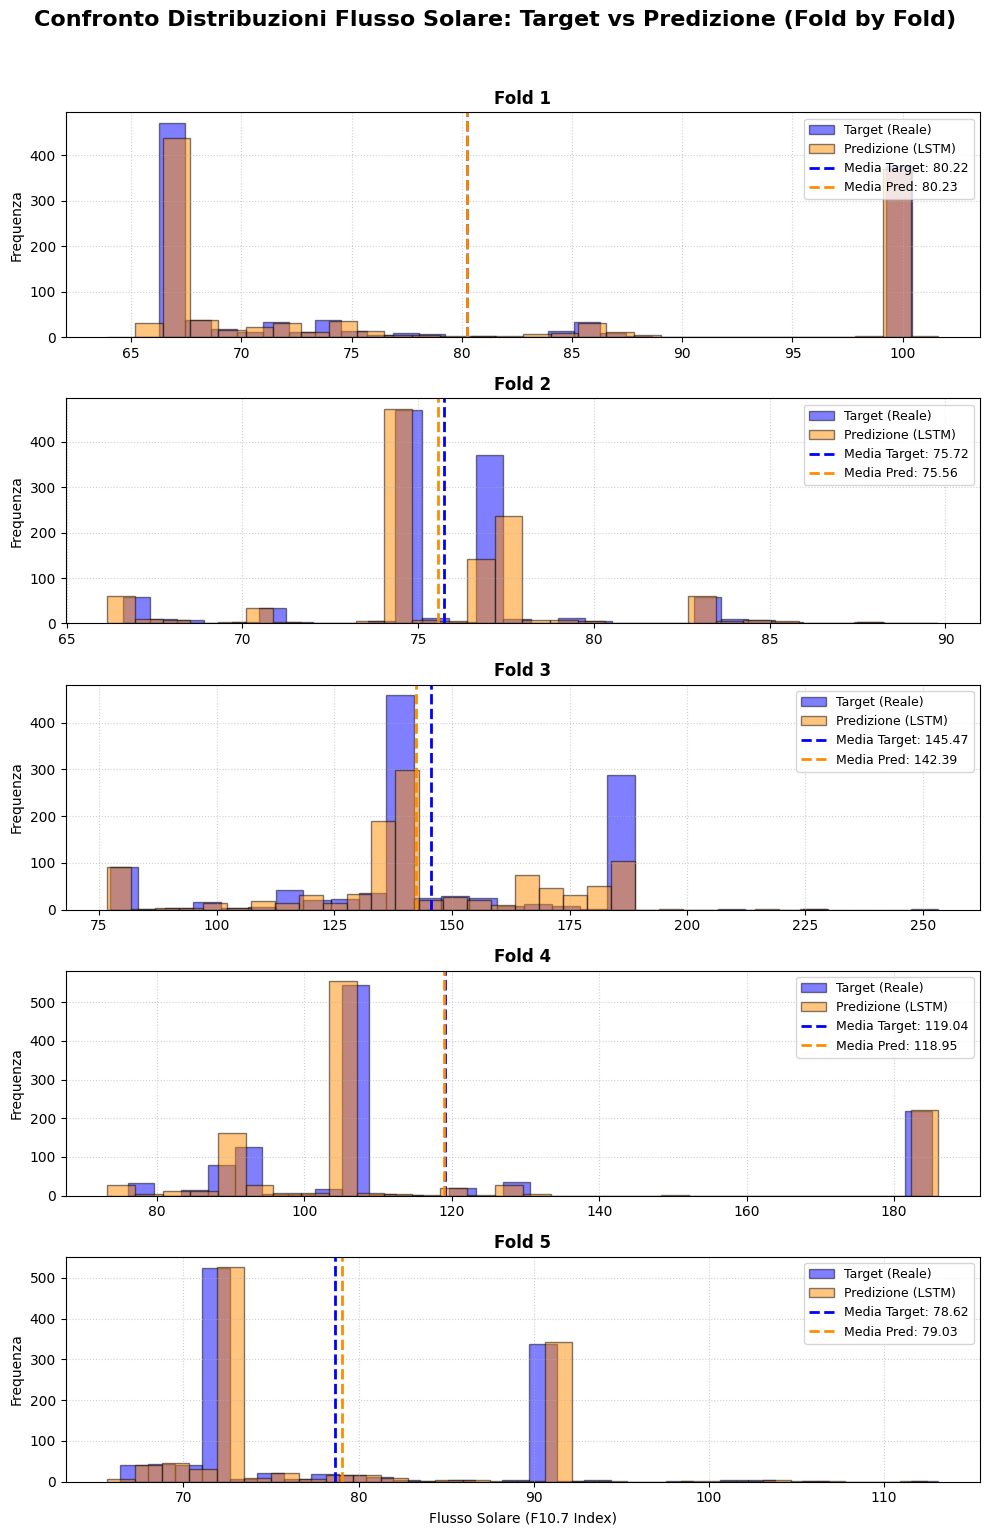

In [21]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from models.LSTM import LSTMRegressor
from utils.train_pytorch_model import train_pytorch_model
from datetime import datetime

print("--- 1. Inizio K-Fold Cross Validation per LSTM ---")

# Definiamo 5 fold senza rimescolamento (blocchi temporali)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

# Dizionari per salvare i risultati di ogni fold
fold_results = {}

# Uniamo temporaneamente tutto il dataset per passarlo al K-Fold
# 1. Scaliamo SOLO il flusso su tutto il dataset
X_flux_scaled = scaler_X_flux.fit_transform(X_flux)

# 2. Espandiamo la dimensione per farla diventare (Campioni, 30, 1)
X_flux_scaled_3d = np.expand_dims(X_flux_scaled, axis=-1)

# 3. Concateniamo con il tempo (che è già (Campioni, 30, 2) e tra -1 e 1)
X_lstm_all = np.concatenate((X_flux_scaled_3d, X_time), axis=-1)

# Il target viene scalato normalmente
y_all_scaled = scaler_y.fit_transform(y.reshape(-1, 1))
y_all_scaled = scaler_y.fit_transform(y.reshape(-1, 1))
timestamp_exp = datetime.now().strftime("%Y%m%d_%H%M%S")

fold = 1
for train_idx, test_idx in kf.split(X_lstm_all):
    print(f"\n>> Esecuzione Fold {fold}/{n_splits}...")
    
    # Divisione Train/Test per il fold corrente
    X_train_f, X_test_f = X_lstm_all[train_idx], X_lstm_all[test_idx]
    y_train_f, y_test_f = y_all_scaled[train_idx], y_all_scaled[test_idx]
    
    # Addestramento di una nuova LSTM per questo fold 
    model_f, device_f, _ = train_pytorch_model(
        X_train=X_train_f, y_train=y_train_f, input_dim=3,
        model_class=LSTMRegressor, epochs=1000, patience=8, 
        batch_size=64, hidden_dim=256
    )
    
    # Inferenza sul Test Set del fold
    model_f.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test_f, dtype=torch.float32).to(device_f)
        y_pred_scaled = model_f(X_test_tensor).cpu().numpy()
    
    # Denormalizzazione
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_target_real = scaler_y.inverse_transform(y_test_f).flatten()
    
    # Calcolo delle medie richieste per questo fold
    mean_target = np.mean(y_target_real)
    mean_pred = np.mean(y_pred_real)
    
    # Salvataggio dati
    fold_results[fold] = {
        'targets': y_target_real,
        'preds': y_pred_real,
        'mean_target': mean_target,
        'mean_pred': mean_pred
    }

    df_fold = pd.DataFrame({
        'Target_F10_7': y_target_real,
        'Predicted_F10_7': y_pred_real
    })
    
    nome_file = f"predizioni_fold_{fold}_{timestamp_exp}.csv"
    
    # Salvataggio su disco 
    df_fold.to_csv(nome_file, index=False)
    
    print(f"   Media Target: {mean_target:.2f} | Media Predetta: {mean_pred:.2f} | Salvato su {nome_file}")

    fold += 1

print("\n--- 2. Generazione Grafici delle Distribuzioni (Istogrammi) ---")

# Creiamo una figura con N righe (una per fold)
fig, axes = plt.subplots(nrows=n_splits, ncols=1, figsize=(10, 3 * n_splits))
fig.suptitle("Confronto Distribuzioni Flusso Solare: Target vs Predizione (Fold by Fold)", fontsize=16, fontweight='bold', y=1.02)

for i in range(1, n_splits + 1):
    ax = axes[i-1]
    data = fold_results[i]
    
    # Plot degli istogrammi in semitrasparenza (alpha) per vedere le sovrapposizioni
    ax.hist(data['targets'], bins=30, alpha=0.5, color='blue', label='Target (Reale)', edgecolor='black')
    ax.hist(data['preds'], bins=30, alpha=0.5, color='darkorange', label='Predizione (LSTM)', edgecolor='black')
    
    # Aggiungiamo le linee verticali per evidenziare le medie
    ax.axvline(data['mean_target'], color='blue', linestyle='dashed', linewidth=2, label=f"Media Target: {data['mean_target']:.2f}")
    ax.axvline(data['mean_pred'], color='darkorange', linestyle='dashed', linewidth=2, label=f"Media Pred: {data['mean_pred']:.2f}")
    
    ax.set_title(f"Fold {i}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Frequenza")
    if i == n_splits:
        ax.set_xlabel("Flusso Solare (F10.7 Index)")
    
    # Spostiamo la legenda fuori o in una posizione che non copra i dati
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


--- 3. Generazione Grafici Andamento Temporale e Calcolo Wasserstein ---
Grafico dell'andamento salvato con successo: andamento_temporale_wasserstein_20260723_125633.pdf
Grafico degli istogrammi salvato con successo: istogrammi_distribuzioni_20260723_125633.pdf


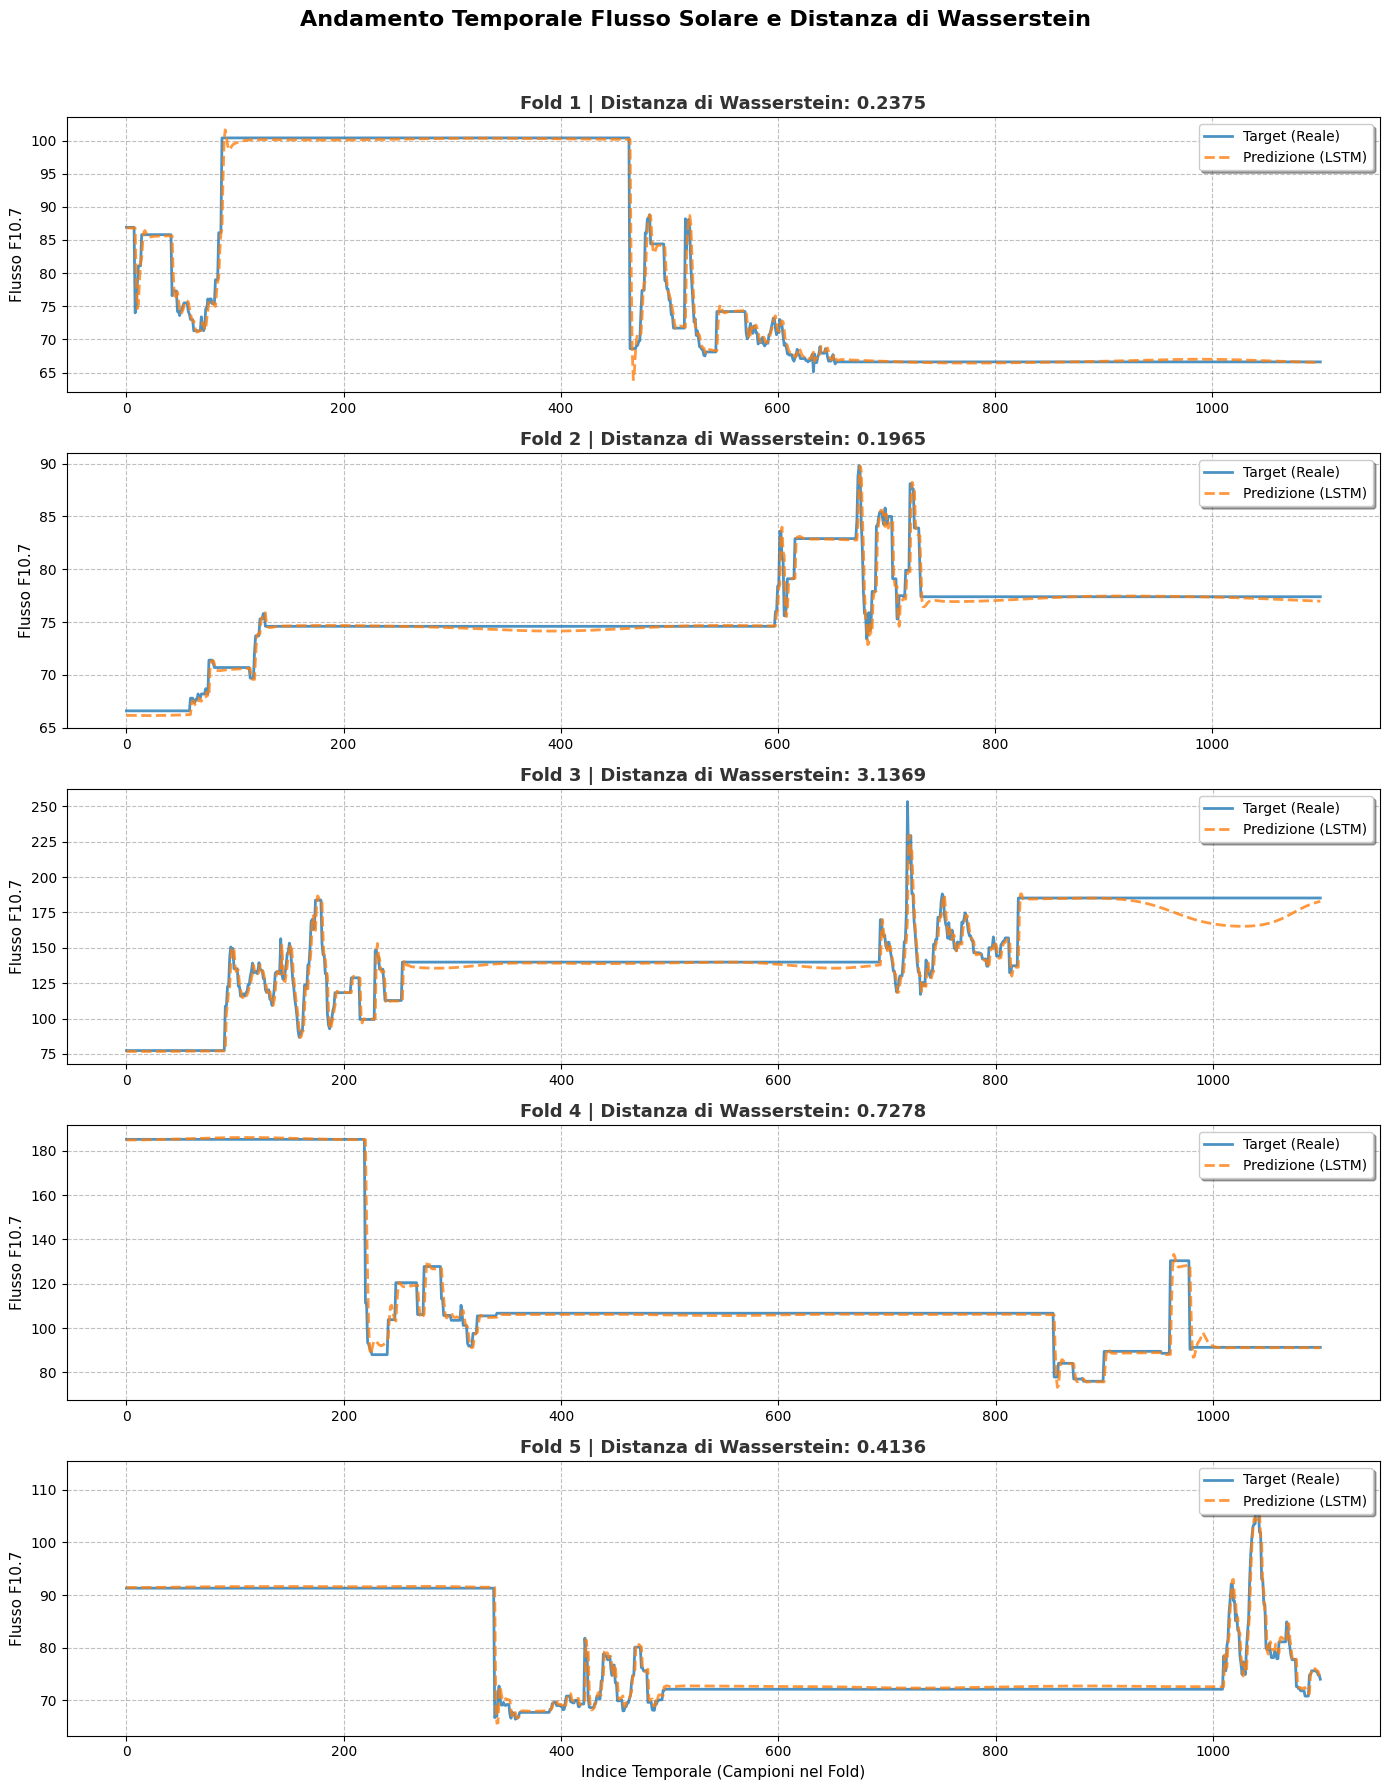

In [22]:
# =====================================================================
# --- 3. Andamento Temporale e Distanza di Wasserstein (Nuovo Blocco) ---
# =====================================================================
from scipy.stats import wasserstein_distance

print("\n--- 3. Generazione Grafici Andamento Temporale e Calcolo Wasserstein ---")

# Creiamo una nuova figura per l'andamento temporale (line plots)
# Usiamo dimensioni ampie per garantire chiarezza: 12 di larghezza, altezza proporzionale ai fold
fig_line, axes_line = plt.subplots(nrows=n_splits, ncols=1, figsize=(14, 3.5 * n_splits))
fig_line.suptitle("Andamento Temporale Flusso Solare e Distanza di Wasserstein", 
                  fontsize=16, fontweight='bold', y=1.02)

for i in range(1, n_splits + 1):
    # Gestione sicura degli assi nel caso n_splits fosse 1
    ax = axes_line[i-1] if n_splits > 1 else axes_line
    
    # Recuperiamo i dati dal dizionario che hai popolato in precedenza
    data = fold_results[i]
    y_t = data['targets']
    y_p = data['preds']
    
    # Calcolo della Distanza di Wasserstein
    w_dist = wasserstein_distance(y_t, y_p)
    
    # Plot dell'andamento: asse X = indice temporale, asse Y = valore flusso
    ax.plot(y_t, label='Target (Reale)', color='#1f77b4', linewidth=2, alpha=0.8)
    ax.plot(y_p, label='Predizione (LSTM)', color='#ff7f0e', linewidth=2, alpha=0.8, linestyle='--')
    
    # Formattazione accattivante e chiara
    ax.set_title(f"Fold {i} | Distanza di Wasserstein: {w_dist:.4f}", fontsize=13, fontweight='bold', color='#333333')
    ax.set_ylabel("Flusso F10.7", fontsize=11)
    
    if i == n_splits:
        ax.set_xlabel("Indice Temporale (Campioni nel Fold)", fontsize=11)
        
    ax.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.legend(loc='upper right', frameon=True, shadow=True)

# Aggiusta automaticamente i margini per non sovrapporre i testi
plt.tight_layout()

timestamp_exp_1 = datetime.now().strftime("%Y%m%d_%H%M%S")

# Salvataggio in formato PDF con timestamp univoco
# Assicurati di essere nella cartella corretta di tmux prima di lanciare lo script
pdf_filename_line = f"andamento_temporale_wasserstein_{timestamp_exp_1}.pdf"
fig_line.savefig(pdf_filename_line, format='pdf', bbox_inches='tight', dpi=300)
print(f"Grafico dell'andamento salvato con successo: {pdf_filename_line}")

pdf_filename_hist = f"istogrammi_distribuzioni_{timestamp_exp_1}.pdf"
fig.savefig(pdf_filename_hist, format='pdf', bbox_inches='tight', dpi=300)
print(f"Grafico degli istogrammi salvato con successo: {pdf_filename_hist}")

plt.show()

## Monthly prediction of solar flux f10_7 and training of neural network using such engineered feature instead of the original one

In [23]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

# Assicuriamoci di avere le funzioni utilities caricate
from models.LSTM import LSTMRegressor
from models.neural_network import NeurNet 
from utils.train_pytorch_model import train_pytorch_model
from utils.data_processing import load_and_preprocess_data

In [24]:

# Prepariamo gli indici temporali per l'Expanding Window
# 'y' inizia dopo LOOKBACK_WINDOW giorni.
valid_dates = df_daily['datetime'].iloc[LOOKBACK_WINDOW:].reset_index(drop=True)

# Creiamo una serie con l'indicazione "Anno-Mese" per poter iterare mese per mese
valid_months = valid_dates.dt.to_period('M')
unique_months = valid_months.unique()

# Decidiamo da dove far partire la simulazione (es. l'ultimo 20% dei mesi disponibili)
start_month_idx = int(len(unique_months) * 0.8)

print(f"Totale mesi disponibili: {len(unique_months)}")
print(f"La simulazione Walk-Forward partirà dal mese: {unique_months[start_month_idx]}")

print("\n=== FASE 2: Walk-Forward Validation (Expanding Window) sull'LSTM ===")

walk_forward_preds = []
walk_forward_dates = []

Totale mesi disponibili: 181
La simulazione Walk-Forward partirà dal mese: 2018-01

=== FASE 2: Walk-Forward Validation (Expanding Window) sull'LSTM ===


In [26]:
# Iteriamo mese per mese
for i in range(start_month_idx, len(unique_months)):
    target_month = unique_months[i]
    print(f"\n>> Training fino a: {target_month - 1} | Predizione per: {target_month}")
    
    # MASCHERE BOOLEANE: Dividiamo passato (Train) e presente (Test)
    train_mask = valid_months < target_month
    test_mask = valid_months == target_month
    
    # Slicing dei dati veri
    X_flux_train_wf = X_flux[train_mask]
    X_time_train_wf = X_time[train_mask]
    y_train_wf = y[train_mask]
    
    X_flux_test_wf = X_flux[test_mask]
    X_time_test_wf = X_time[test_mask]
    y_test_wf = y[test_mask]
    dates_test_wf = valid_dates[test_mask]
    
    # Scaliamo SOLO i dati che ne hanno bisogno per evitare data leakage
    # (Il tempo NON viene scalato perché seno e coseno sono già tra -1 e 1)
    scaler_X_flux_wf = MinMaxScaler()
    scaler_y_wf = MinMaxScaler()
    
    # 1. Scaliamo il target
    y_train_scaled_wf = scaler_y_wf.fit_transform(y_train_wf.reshape(-1, 1))
    
    # 2. Scaliamo il flusso (che è 2D: Campioni, 30)
    X_flux_train_scaled = scaler_X_flux_wf.fit_transform(X_flux_train_wf)
    X_flux_test_scaled = scaler_X_flux_wf.transform(X_flux_test_wf)
    
    # 3. Aggiungiamo l'ultima dimensione per renderli 3D (Campioni, 30, 1)
    X_flux_train_3d = np.expand_dims(X_flux_train_scaled, axis=-1)
    X_flux_test_3d = np.expand_dims(X_flux_test_scaled, axis=-1)
    
    # 4. Concateniamo lungo l'ultimo asse con il tempo (che è già 3D) -> (Campioni, 30, 3)
    X_lstm_train_wf = np.concatenate((X_flux_train_3d, X_time_train_wf), axis=-1)
    X_lstm_test_wf = np.concatenate((X_flux_test_3d, X_time_test_wf), axis=-1)
    
    # Addestriamo l'LSTM (Epoche ridotte a 1000 per bilanciare i tempi del loop)
    model_wf, device_wf, _ = train_pytorch_model(
        X_train=X_lstm_train_wf, 
        y_train=y_train_scaled_wf, 
        input_dim=3,                # <--- CORREZIONE: 1 (Flusso) + 2 (Tempo)
        model_class=LSTMRegressor, 
        epochs=1000, patience=8, 
        batch_size=64, hidden_dim=256
    )
    
    # Inferenza sul mese target
    model_wf.eval()
    with torch.no_grad():
        X_test_tensor_wf = torch.tensor(X_lstm_test_wf, dtype=torch.float32).to(device_wf)
        y_pred_scaled_wf = model_wf(X_test_tensor_wf).cpu().numpy()
        
    # Denormalizzazione
    y_pred_real_wf = scaler_y_wf.inverse_transform(y_pred_scaled_wf).flatten()
    
    # Salviamo i risultati di questo mese
    walk_forward_preds.extend(y_pred_real_wf)
    walk_forward_dates.extend(dates_test_wf.values)


>> Training fino a: 2017-12 | Predizione per: 2018-01


Training:   0%|                                                                                                                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 58

>> Training fino a: 2018-01 | Predizione per: 2018-02


Early stopping at epoch 65

>> Training fino a: 2018-02 | Predizione per: 2018-03


Early stopping at epoch 60

>> Training fino a: 2018-03 | Predizione per: 2018-04


...

Early stopping at epoch 21

>> Training fino a: 2020-09 | Predizione per: 2020-10


Early stopping at epoch 15

>> Training fino a: 2020-10 | Predizione per: 2020-11


Early stopping at epoch 13

>> Training fino a: 2020-11 | Predizione per: 2020-12


Early stopping at epoch 32

>> Training fino a: 2020-12 | Predizione per: 2021-01


Early stopping at epoch 31


In [27]:
print("\n=== FASE 3: Sostituzione dei dati e Merge (Scenario Cascata) ===")

# Creiamo il DataFrame con tutte le predizioni continue del Walk-Forward
df_wf_blind_test = pd.DataFrame({
    'datetime': walk_forward_dates,
    'Predicted_F10_7': walk_forward_preds
})
split_date_wf = df_wf_blind_test['datetime'].min()

# Filtriamo la deep copy di MARSIS per prendere solo il periodo di Test
df_main_copy['datetime'] = pd.to_datetime(df_main_copy['FM_data_ephemeris_time'], unit='s', origin=pd.Timestamp('2000-01-01 12:00:00'))
df_marsis_test_wf = df_main_copy[df_main_copy['datetime'] >= split_date_wf].copy()

# Allineamento temporale nanosecondi
df_marsis_test_wf['datetime'] = df_marsis_test_wf['datetime'].astype('datetime64[ns]')
df_wf_blind_test['datetime'] = df_wf_blind_test['datetime'].astype('datetime64[ns]')

df_marsis_test_wf = df_marsis_test_wf.sort_values('datetime').reset_index(drop=True)
df_wf_blind_test = df_wf_blind_test.sort_values('datetime').reset_index(drop=True)

# Merge: associamo le predizioni mensili al radar
df_cascade_wf = pd.merge_asof(
    df_marsis_test_wf,
    df_wf_blind_test,
    on='datetime',
    direction='backward'
)
df_cascade_wf = df_cascade_wf.dropna(subset=['Predicted_F10_7'])

# Creiamo lo scenario Ideale (dati veri)
df_test_ideal_wf = df_cascade_wf.copy(deep=True)

# Creiamo lo scenario Cascata (sostituiamo i dati veri con la predizione LSTM)
df_test_cascade_wf = df_cascade_wf.copy(deep=True)
df_test_cascade_wf['FM_data_F10_7_index'] = df_test_cascade_wf['Predicted_F10_7']

# rimuoviamo le colonne di appoggio prima del salvataggio
df_test_ideal_wf = df_test_ideal_wf.drop(columns=['Predicted_F10_7', 'datetime'], errors='ignore')
df_test_cascade_wf = df_test_cascade_wf.drop(columns=['Predicted_F10_7', 'datetime'], errors='ignore')

timestamp_wf = datetime.now().strftime("%Y%m%d_%H%M%S")

# Definiamo i percorsi dei 3 file includendo il timestamp
ideal_csv_path = f"../Data/Test_Sets/MARSIS_Test_Ideal_WF_{timestamp_wf}.csv"
cascade_csv_path = f"../Data/Test_Sets/MARSIS_Test_Cascade_WF_{timestamp_wf}.csv"
train_csv_path = f"../Data/Test_Sets/MARSIS_Train_Pure_WF_{timestamp_wf}.csv"

# Salvataggio file di TEST
os.makedirs("../Data/Test_Sets", exist_ok=True)
df_test_ideal_wf.to_csv(ideal_csv_path, sep=";", index=False)
df_test_cascade_wf.to_csv(cascade_csv_path, sep=";", index=False)

# Usiamo la parte antecedente alla split_date per il Train della Rete Neurale e la puliamo
df_marsis_train_wf = df_main_copy[df_main_copy['datetime'] < split_date_wf].copy()
df_marsis_train_wf = df_marsis_train_wf.drop(columns=['datetime'], errors='ignore')

# Salvataggio file di TRAIN con timestamp
df_marsis_train_wf.to_csv(train_csv_path, sep=";", index=False)

print(f"File salvati in modo univoco:\n- {ideal_csv_path}\n- {cascade_csv_path}\n- {train_csv_path}")


=== FASE 3: Sostituzione dei dati e Merge (Scenario Cascata) ===
File salvati in modo univoco:
- ../Data/Test_Sets/MARSIS_Test_Ideal_WF_20260723_133800.csv
- ../Data/Test_Sets/MARSIS_Test_Cascade_WF_20260723_133800.csv
- ../Data/Test_Sets/MARSIS_Train_Pure_WF_20260723_133800.csv



=== FASE 4: Estrazione, Addestramento NN e Valutazione Finale ===


Early stopping at epoch 11
REPORT FINALE: ESPERIMENTO A CASCATA CON WALK-FORWARD (MESE PER MESE)
SCENARIO 1: FLUSSO REALE       -> MAE: 2.7508
SCENARIO 2: FLUSSO PREDETTO WF -> MAE: 2.7501
Degrado delle performance:  +-0.03%


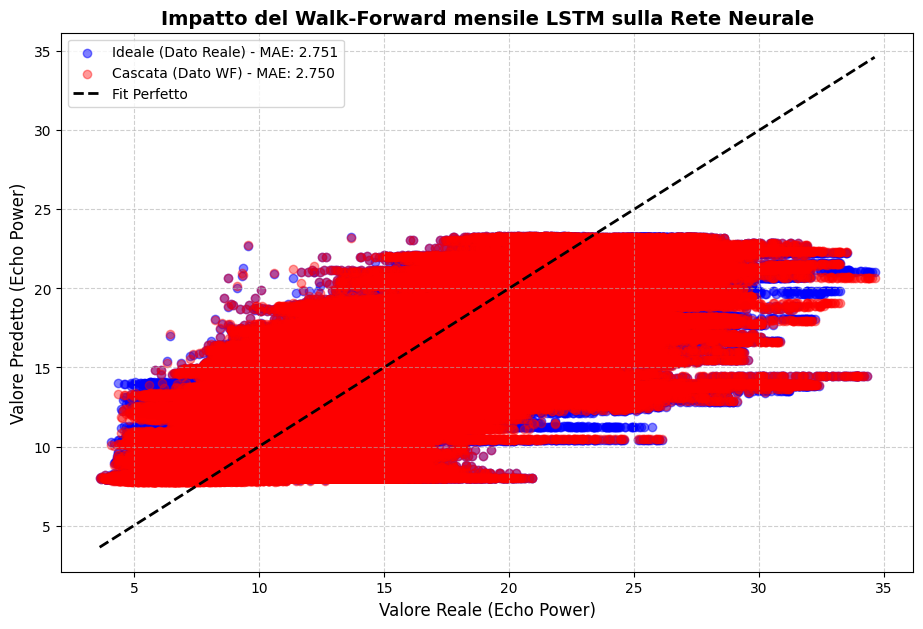

In [28]:
print("\n=== FASE 4: Estrazione, Addestramento NN e Valutazione Finale ===")
orbit_file_path = "../Data/orbit_to_remove" 

# Carichiamo tramite la pipeline, usando le VARIABILI dinamiche appena create
X_train_nn, y_train_nn, _ = load_and_preprocess_data(dataset_path=train_csv_path, orbit_path=orbit_file_path, keep_flux=True)
X_test_ideal_nn, y_test_ideal_nn, _ = load_and_preprocess_data(dataset_path=ideal_csv_path, orbit_path=orbit_file_path, keep_flux=True)
X_test_cascade_nn, y_test_cascade_nn, _ = load_and_preprocess_data(dataset_path=cascade_csv_path, orbit_path=orbit_file_path, keep_flux=True)

# Standardizzazione Rete Neurale
scaler_nn_wf = StandardScaler()
X_train_nn_scaled = scaler_nn_wf.fit_transform(X_train_nn)
X_test_ideal_nn_scaled = scaler_nn_wf.transform(X_test_ideal_nn)
X_test_cascade_nn_scaled = scaler_nn_wf.transform(X_test_cascade_nn)

# Addestramento della Rete Neurale Principale (sui dati passati veri)
main_model_wf, device_nn, _ = train_pytorch_model(
    X_train=X_train_nn_scaled, y_train=y_train_nn, input_dim=X_train_nn_scaled.shape[1],
    model_class=NeurNet, epochs=1000, patience=10, batch_size=256
)

# Inferenza Scenari
main_model_wf.eval()
with torch.no_grad():
    X_ideal_tensor_wf = torch.tensor(X_test_ideal_nn_scaled, dtype=torch.float32).to(device_nn)
    X_cascade_tensor_wf = torch.tensor(X_test_cascade_nn_scaled, dtype=torch.float32).to(device_nn)
    
    y_pred_ideal_nn = main_model_wf(X_ideal_tensor_wf).cpu().numpy().flatten()
    y_pred_cascade_nn = main_model_wf(X_cascade_tensor_wf).cpu().numpy().flatten()

# Calcolo Metriche
mae_ideal_nn = mean_absolute_error(y_test_ideal_nn, y_pred_ideal_nn)
mae_cascade_nn = mean_absolute_error(y_test_cascade_nn, y_pred_cascade_nn)

print("="*60)
print("REPORT FINALE: ESPERIMENTO A CASCATA CON WALK-FORWARD (MESE PER MESE)")
print("="*60)
print(f"SCENARIO 1: FLUSSO REALE       -> MAE: {mae_ideal_nn:.4f}")
print(f"SCENARIO 2: FLUSSO PREDETTO WF -> MAE: {mae_cascade_nn:.4f}")
print(f"Degrado delle performance:  +{((mae_cascade_nn - mae_ideal_nn) / mae_ideal_nn) * 100:.2f}%")
print("="*60)

# Grafico Comparativo Finale (Salvato su disco)
plt.figure(figsize=(11, 7))
plt.scatter(y_test_ideal_nn, y_pred_ideal_nn, alpha=0.5, color='blue', label=f'Ideale (Dato Reale) - MAE: {mae_ideal_nn:.3f}')
plt.scatter(y_test_cascade_nn, y_pred_cascade_nn, alpha=0.4, color='red', label=f'Cascata (Dato WF) - MAE: {mae_cascade_nn:.3f}')
plt.plot([y_test_ideal_nn.min(), y_test_ideal_nn.max()], [y_test_ideal_nn.min(), y_test_ideal_nn.max()], 'k--', lw=2, label='Fit Perfetto')

plt.title('Impatto del Walk-Forward mensile LSTM sulla Rete Neurale', fontsize=14, fontweight='bold')
plt.xlabel('Valore Reale (Echo Power)', fontsize=12)
plt.ylabel('Valore Predetto (Echo Power)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

timestamp_plot_exp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.savefig(f"confronto_cascata_WF_{timestamp_plot_exp}.pdf", format='pdf', bbox_inches='tight')
plt.show()